In [1]:
# -*- coding: utf-8 -*-

def main():
    # 1) 已知的 kc_name -> que_diff_mean
    kc_to_que_diff = {
        28: 0.315155,
        14: 0.196154,
        27: -0.082294,
        16: -0.089265,
        17: -0.165762,
        18: -0.313951,
        10: -0.402821,
        15: -0.553444,
        11: -0.569418,
        9: -0.621420,
        12: -0.745072,
        13: -0.761245,
        6: -0.830850,
        8: -0.862276,
        4: -0.880928,
        7: -0.884346,
        3: -0.922177,
        2: -0.937765,
        5: -0.942724,
        1: -0.947440,
        0: -0.947568,
    }

    # 2) 已知的 difficulty_level -> kc_name
    difficulty_to_kc = {
        0: 0,
        1: 1,
        4: 2,
        5: 3,
        3: 4,
        2: 5,
        6: 6,
        7: 7,
        8: 8,
        9: 9,
        10: 10,
        11: 11,
        12: 12,
        13: 13,
        17: 14,
        16: 15,
        15: 16,
        28: 17,
        14: 18,
        18: 19,
        20: 20,
        27: 21,
        25: 22,
        21: 23,
        19: 24,
        30: 25,
        31: 26,
        26: 27,
        39: 28,
        44: 29,
        22: 30,
        46: 31,
        45: 32,
        24: 33,
        23: 34,
        42: 35,
        166: 36,
        33: 37,
        36: 38,
        35: 39,
    }

    # 3) 反推 difficulty_level -> que_diff_mean
    difficulty_to_que_diff = {}
    for difficulty_level, kc_name in difficulty_to_kc.items():
        difficulty_to_que_diff[difficulty_level] = kc_to_que_diff.get(kc_name, None)

    # 4) 打印结果（按 difficulty_level 升序）
    print("difficulty_level -> kc_name -> que_diff_mean")
    print("-" * 50)
    for difficulty_level in sorted(difficulty_to_que_diff.keys()):
        kc_name = difficulty_to_kc[difficulty_level]
        que_diff_mean = difficulty_to_que_diff[difficulty_level]

        if que_diff_mean is None:
            que_diff_str = "None"
        else:
            que_diff_str = f"{que_diff_mean:.6f}"

        print(
            f"difficulty_level={difficulty_level:>3} | "
            f"kc_name={kc_name:>3} | "
            f"que_diff_mean={que_diff_str}"
        )

    # 5) 只输出已知的 difficulty_level -> que_diff_mean 字典
    known_only = {
        difficulty_level: que_diff
        for difficulty_level, que_diff in difficulty_to_que_diff.items()
        if que_diff is not None
    }

    print("\n只保留已知 que_diff_mean 的结果：")
    print(known_only)

    # 6) 统计
    total = len(difficulty_to_que_diff)
    known = sum(v is not None for v in difficulty_to_que_diff.values())
    unknown = total - known

    print("\n统计信息：")
    print(f"总 difficulty_level 数量: {total}")
    print(f"已成功反推数量: {known}")
    print(f"未知数量: {unknown}")


if __name__ == "__main__":
    main()

difficulty_level -> kc_name -> que_diff_mean
--------------------------------------------------
difficulty_level=  0 | kc_name=  0 | que_diff_mean=-0.947568
difficulty_level=  1 | kc_name=  1 | que_diff_mean=-0.947440
difficulty_level=  2 | kc_name=  5 | que_diff_mean=-0.942724
difficulty_level=  3 | kc_name=  4 | que_diff_mean=-0.880928
difficulty_level=  4 | kc_name=  2 | que_diff_mean=-0.937765
difficulty_level=  5 | kc_name=  3 | que_diff_mean=-0.922177
difficulty_level=  6 | kc_name=  6 | que_diff_mean=-0.830850
difficulty_level=  7 | kc_name=  7 | que_diff_mean=-0.884346
difficulty_level=  8 | kc_name=  8 | que_diff_mean=-0.862276
difficulty_level=  9 | kc_name=  9 | que_diff_mean=-0.621420
difficulty_level= 10 | kc_name= 10 | que_diff_mean=-0.402821
difficulty_level= 11 | kc_name= 11 | que_diff_mean=-0.569418
difficulty_level= 12 | kc_name= 12 | que_diff_mean=-0.745072
difficulty_level= 13 | kc_name= 13 | que_diff_mean=-0.761245
difficulty_level= 14 | kc_name= 18 | que_diff_mean

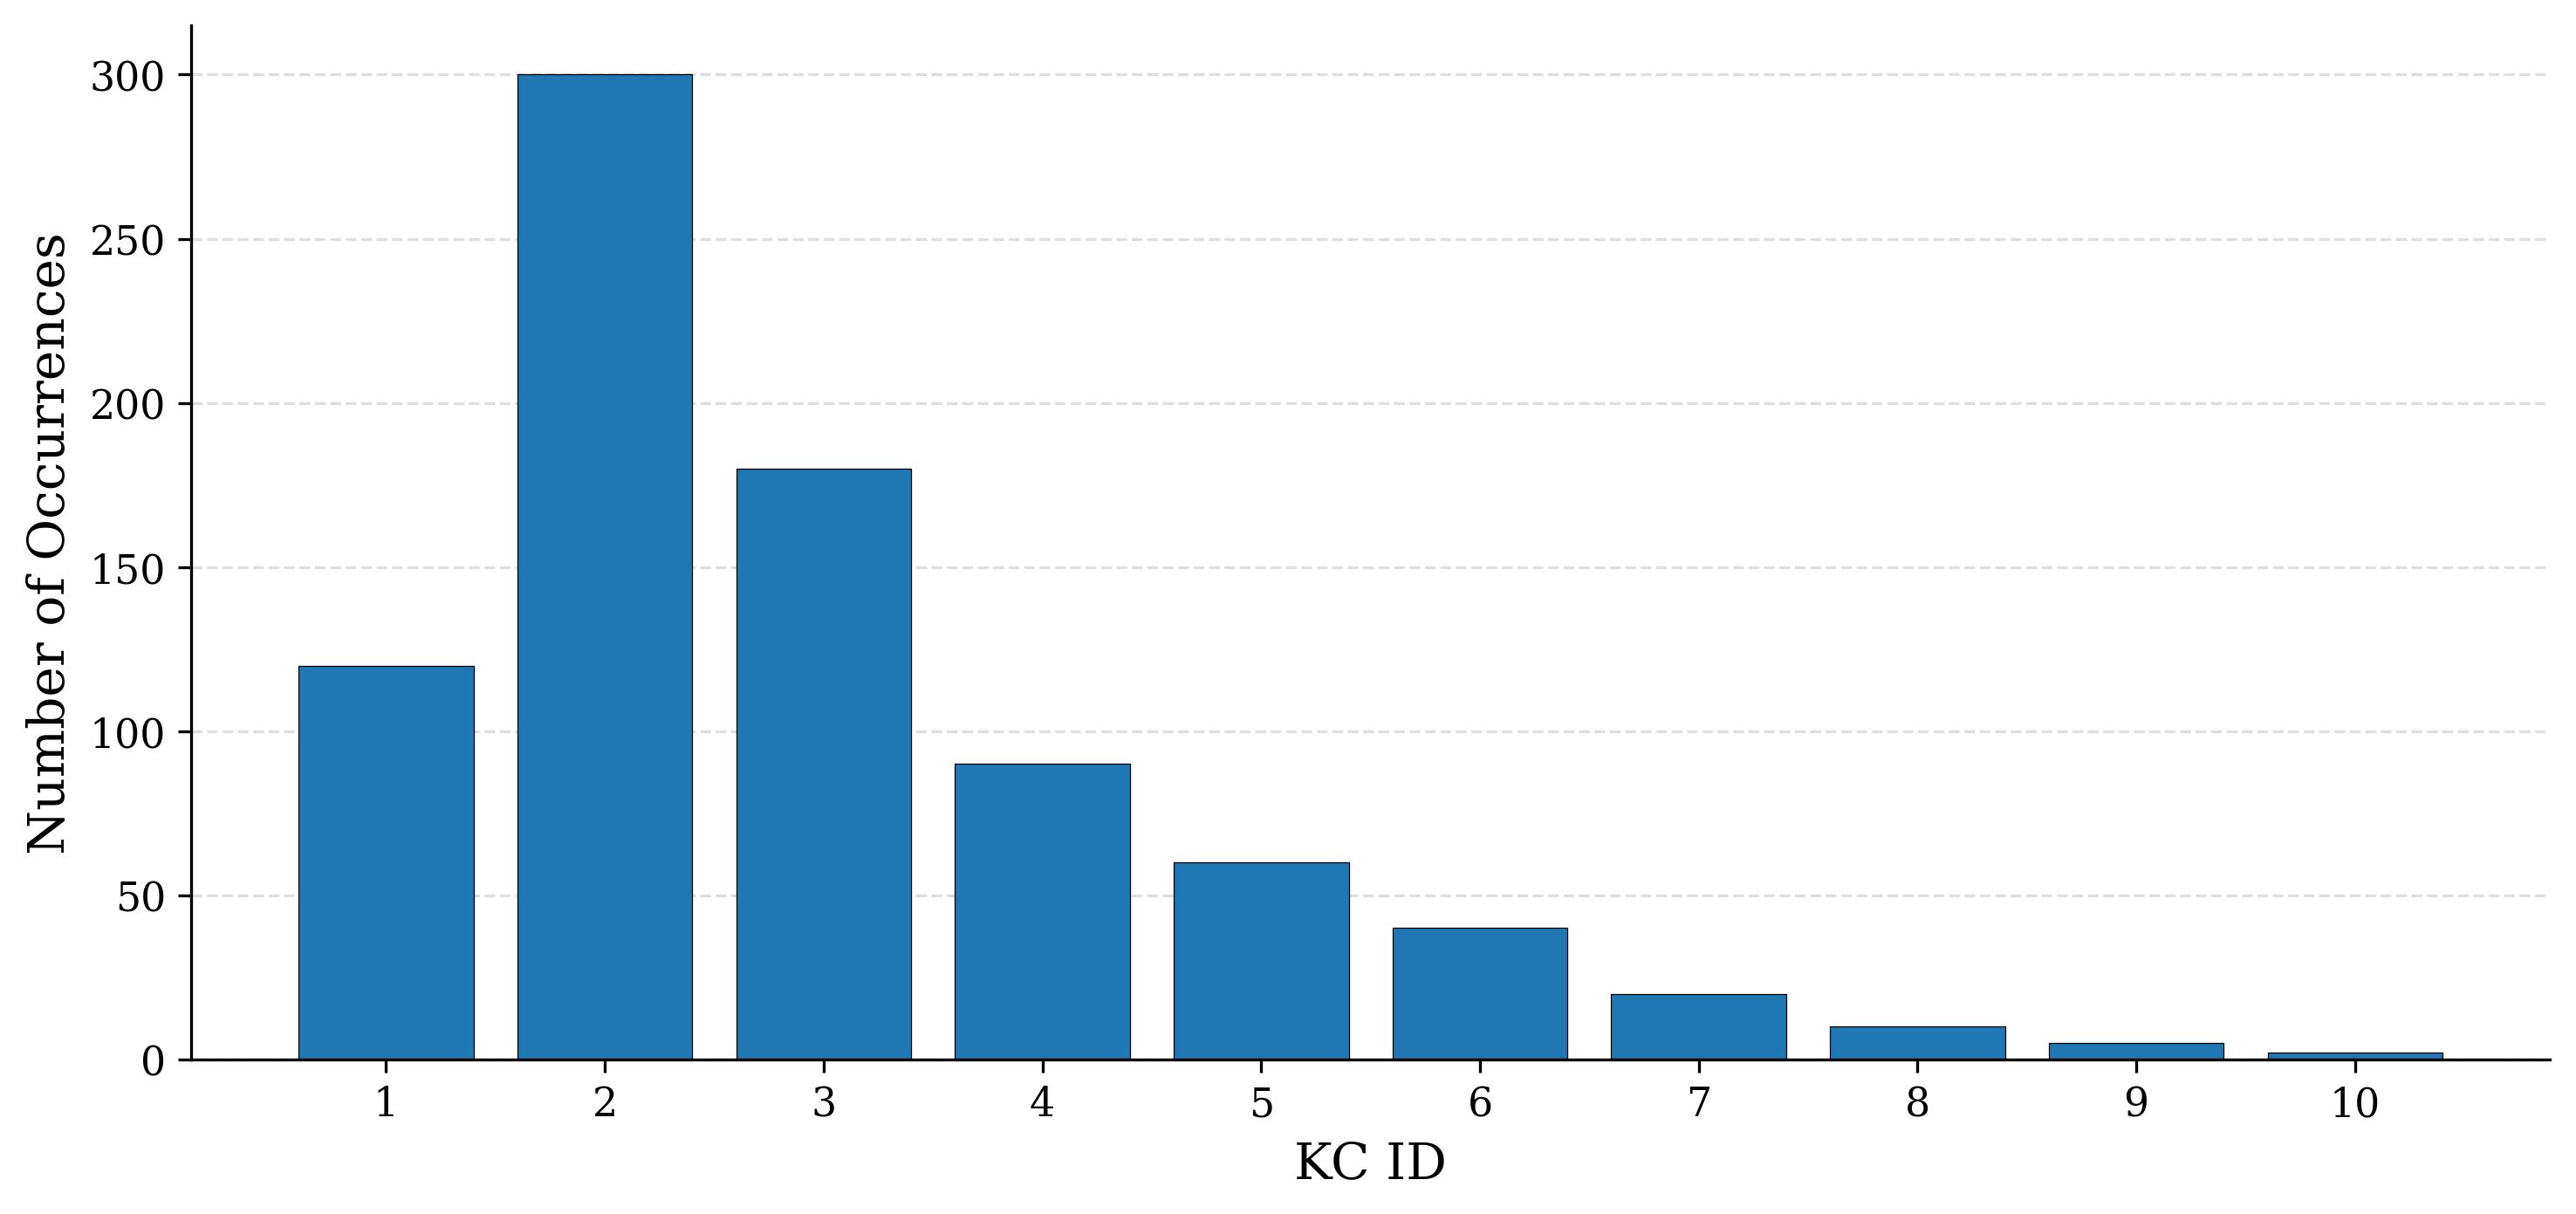

In [3]:
# 测试打印
import matplotlib.pyplot as plt
import numpy as np

# Example
kc_ids = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
counts = np.array([120, 300, 180, 90, 60, 40, 20, 10, 5, 2])

def plot_kc_distribution(kc_ids, counts, save_path=None):
    # Sort by KC ID if needed
    order = np.argsort(kc_ids)
    kc_ids = np.array(kc_ids)[order]
    counts = np.array(counts)[order]

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 12,
        "axes.labelsize": 14,
        "axes.titlesize": 14,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
    })

    fig, ax = plt.subplots(figsize=(10, 4.8), dpi=300)

    ax.bar(kc_ids, counts, width=0.8, edgecolor="black", linewidth=0.3)

    ax.set_xlabel("KC ID")
    ax.set_ylabel("Number of Occurrences")

    # Only horizontal gridlines
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

    # Remove unnecessary spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Reduce x tick density
    step = max(1, len(kc_ids) // 12)
    ax.set_xticks(kc_ids[::step])

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

plot_kc_distribution(kc_ids, counts, save_path="kc_distribution.pdf")

In [ ]:
#!/bin/bash
#SBATCH -J aktint_1c_predict
#SBATCH -p gpu
#SBATCH --gres=gpu:1
#SBATCH --time=24:00:00
#SBATCH --cpus-per-task=4
#SBATCH --mem=128G
#SBATCH -o logs/%x-%j.out
#SBATCH -e logs/%x-%j.err

set -euo pipefail

# 1) 切到你要跑的目录（很关键：避免相对路径炸掉）
cd ~/my_code/pykt-ukelele/examples

# 2) 激活 conda 环境（两种写法，选一种能用的）
# --- 写法A：最常见（推荐先试这个） ---
source ~/.bashrc
source /home/remote/u8016457/miniconda3/etc/profile.d/conda.sh
conda activate pykt

# --- 写法B：如果上面激活失败，再用这个 ---
# source ~/miniconda3/etc/profile.d/conda.sh
# conda activate pykt

echo "=== Job info ==="
hostname
pwd
which python
python -V
nvidia-smi || true
python -c "import torch; print('torch', torch.__version__, 'cuda', torch.cuda.is_available())"

# 3) 跑你原来的命令
python 
